# Imports

In [113]:
import scanpy as sc
import anndata as ad
import numpy as np
from scipy.stats import median_abs_deviation
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri, pandas2ri
from scipy.sparse import csc_matrix


In [76]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}

In [77]:
adata1 = sc.read_10x_h5('/projects/circ_iri/work/cell_ranger/output/S26_17/outs/filtered_feature_bc_matrix.h5')

/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [78]:
adata1.var_names_make_unique()

In [79]:
adata1

AnnData object with n_obs × n_vars = 16435 × 33696
    var: 'gene_ids', 'feature_types', 'genome'

In [80]:
adata1.obs

""
AAACCAAAGCGCCTGA-1
AAACCAAAGGCGAGAC-1
AAACCAAAGGCTCCGA-1
AAACCAAAGGTGCAGA-1
AAACCAAAGTCGCATA-1
...
TGTGTTAGTAGCTTAC-1
TGTGTTAGTCCCGAGT-1
TGTGTTAGTGCAAGGT-1
TGTGTTGAGAACGGCA-1


In [81]:
adata1.var

,gene_ids,feature_types,genome
Xkr4,ENSMUSG00000051951,Gene Expression,GRCm39
Gm1992,ENSMUSG00000089699,Gene Expression,GRCm39
Gm19938,ENSMUSG00000102331,Gene Expression,GRCm39
Gm37381,ENSMUSG00000102343,Gene Expression,GRCm39
Rp1,ENSMUSG00000025900,Gene Expression,GRCm39
...,...,...,...
ENSMUSG00000095523,ENSMUSG00000095523,Gene Expression,GRCm39
ENSMUSG00000095475,ENSMUSG00000095475,Gene Expression,GRCm39
ENSMUSG00000094855,ENSMUSG00000094855,Gene Expression,GRCm39
ENSMUSG00000095019,ENSMUSG00000095019,Gene Expression,GRCm39


In [82]:
adata1.X.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(16435, 33696), dtype=float32)

In [83]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata1.var["mt"] = adata1.var_names.str.startswith("mt-")
# ribosomal genes
adata1.var["ribo"] = adata1.var_names.str.startswith(("Rps", "Rpl"))
# hemoglobin genes
adata1.var["hb"] = adata1.var_names.str.startswith(("Hba-","Hbb-"))

In [84]:
sc.pp.calculate_qc_metrics(adata1, qc_vars=["mt", "ribo", "hb"], percent_top=(20, 50, 100, 200, 500), inplace=True, log1p=True)

In [85]:
adata1.obs["total_counts"].max()

np.float32(50568.0)

In [86]:
adata1.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
AAACCAAAGCGCCTGA-1,1741,7.462789,2887.0,7.968319,15.587115,21.440942,27.779702,37.062695,57.014202,28.0,3.367296,0.969865,47.0,3.871201,1.627988,3.0,1.386294,0.103914
AAACCAAAGGCGAGAC-1,1458,7.285507,2360.0,7.766840,14.745763,20.932203,28.093220,38.474576,59.406780,32.0,3.496508,1.355932,39.0,3.688879,1.652542,1.0,0.693147,0.042373
AAACCAAAGGCTCCGA-1,2520,7.832411,5668.0,8.642768,18.719125,25.723359,32.163020,40.508116,56.527876,48.0,3.891820,0.846860,63.0,4.158883,1.111503,2.0,1.098612,0.035286
AAACCAAAGGTGCAGA-1,886,6.787845,1103.0,7.006695,10.063463,17.225748,26.291931,37.805984,65.004533,16.0,2.833213,1.450589,25.0,3.258096,2.266546,0.0,0.000000,0.000000
AAACCAAAGTCGCATA-1,1109,7.012115,1730.0,7.456455,14.104046,21.502890,30.635838,42.890173,64.797688,32.0,3.496508,1.849711,48.0,3.891820,2.774566,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTTAGTAGCTTAC-1,996,6.904751,1837.0,7.516433,18.998367,28.851388,38.595536,50.680457,72.999456,64.0,4.174387,3.483941,71.0,4.276666,3.864997,1.0,0.693147,0.054437
TGTGTTAGTCCCGAGT-1,2312,7.746301,4158.0,8.333030,10.173160,15.464165,21.885522,31.168831,49.110149,54.0,4.007333,1.298701,59.0,4.094345,1.418951,3.0,1.386294,0.072150
TGTGTTAGTGCAAGGT-1,1417,7.257003,2164.0,7.680176,9.288355,15.526802,23.243993,34.935305,57.624769,34.0,3.555348,1.571164,44.0,3.806663,2.033272,2.0,1.098612,0.092421
TGTGTTGAGAACGGCA-1,1791,7.491088,2849.0,7.955074,9.828010,15.795016,22.920323,33.380133,54.440154,23.0,3.178054,0.807301,74.0,4.317488,2.597403,1.0,0.693147,0.035100


In [87]:
adata1.var["mt"]

Xkr4                  False
Gm1992                False
Gm19938               False
Gm37381               False
Rp1                   False
                      ...  
ENSMUSG00000095523    False
ENSMUSG00000095475    False
ENSMUSG00000094855    False
ENSMUSG00000095019    False
ENSMUSG00000095041    False
Name: mt, Length: 33696, dtype: bool

In [88]:
adata1.var_names.str.startswith("mt-").sum()
adata1.var[adata1.var_names.str.startswith("mt-")]

,gene_ids,feature_types,genome,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
mt-Nd1,ENSMUSG00000064341,Gene Expression,GRCm39,True,False,False,14452,3.008153,1.388331,12.065713,49439.0,10.808516
mt-Nd2,ENSMUSG00000064345,Gene Expression,GRCm39,True,False,False,12769,1.865166,1.052626,22.306054,30654.0,10.330551
mt-Co1,ENSMUSG00000064351,Gene Expression,GRCm39,True,False,False,16402,18.781746,2.984760,0.200791,308678.0,12.640058
mt-Co2,ENSMUSG00000064354,Gene Expression,GRCm39,True,False,False,15367,4.387709,1.684120,6.498327,72112.0,11.185989
mt-Atp8,ENSMUSG00000064356,Gene Expression,GRCm39,True,False,False,1046,0.067174,0.065014,93.635534,1104.0,7.007601
mt-Atp6,ENSMUSG00000064357,Gene Expression,GRCm39,True,False,False,14266,2.795132,1.333719,13.197444,45938.0,10.735069
mt-Co3,ENSMUSG00000064358,Gene Expression,GRCm39,True,False,False,15582,4.999452,1.791668,5.190143,82166.0,11.316509
mt-Nd3,ENSMUSG00000064360,Gene Expression,GRCm39,True,False,False,3600,0.261454,0.232265,78.095528,4297.0,8.365905
mt-Nd4l,ENSMUSG00000065947,Gene Expression,GRCm39,True,False,False,1548,0.102890,0.097934,90.581077,1691.0,7.433667
mt-Nd4,ENSMUSG00000064363,Gene Expression,GRCm39,True,False,False,14978,3.467113,1.496742,8.865227,56982.0,10.950508


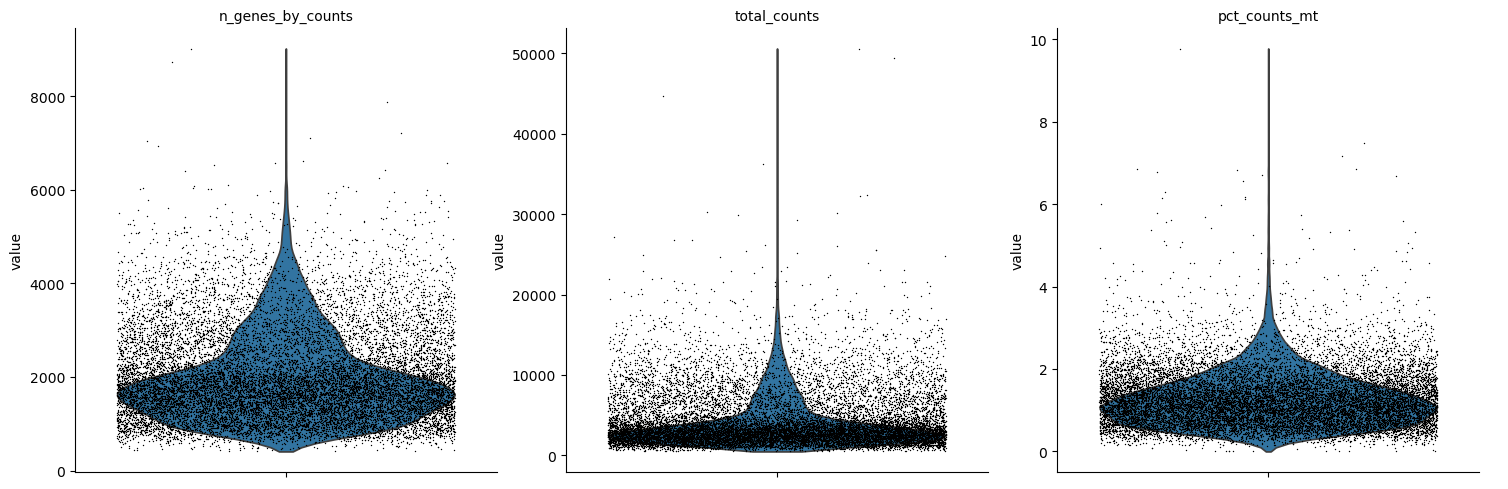

In [89]:
sc.pl.violin(
    adata1,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

(0.0, 30000.0)

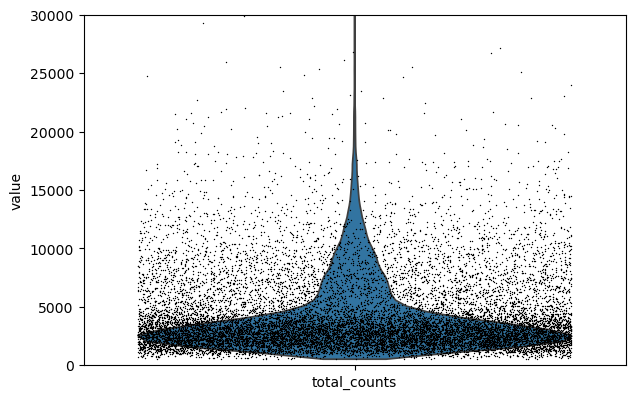

In [90]:
ax = sc.pl.violin(
    adata1,
    "total_counts",
    jitter=0.4,
    show=False
)

ax.set_ylim(0, 30000)

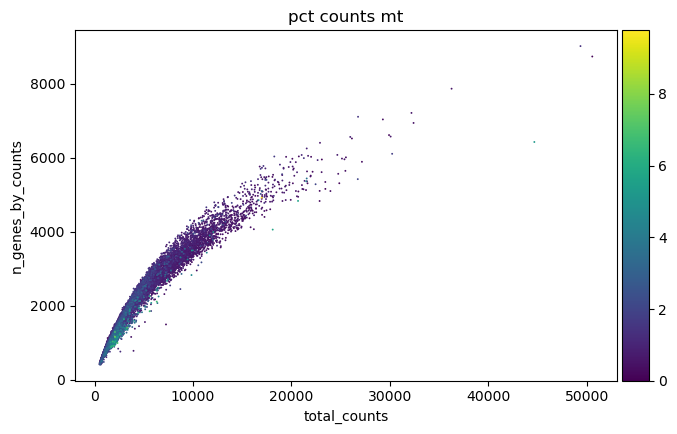

In [91]:
sc.pl.scatter(adata1, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [92]:
def is_outlier(adata1, metric: str, nmads: int):
    M = adata1.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier

In [93]:
adata1.obs["outlier"] = (
    is_outlier(adata1, "log1p_total_counts", 5)
    | is_outlier(adata1, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata1, "pct_counts_in_top_20_genes", 5)
)
adata1.obs.outlier.value_counts()

outlier
False    16229
True       206
Name: count, dtype: int64

In [94]:
adata1.obs["mt_outlier"] = is_outlier(adata1, "pct_counts_mt", 3) | (
    adata1.obs["pct_counts_mt"] > 8
)
adata1.obs.mt_outlier.value_counts()

mt_outlier
False    15428
True      1007
Name: count, dtype: int64

In [95]:
print(f"Total number of cells: {adata1.n_obs}")
adata1 = adata1[(~adata1.obs.outlier) & (~adata1.obs.mt_outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata1.n_obs}")

Total number of cells: 16435
Number of cells after filtering of low quality cells: 15223


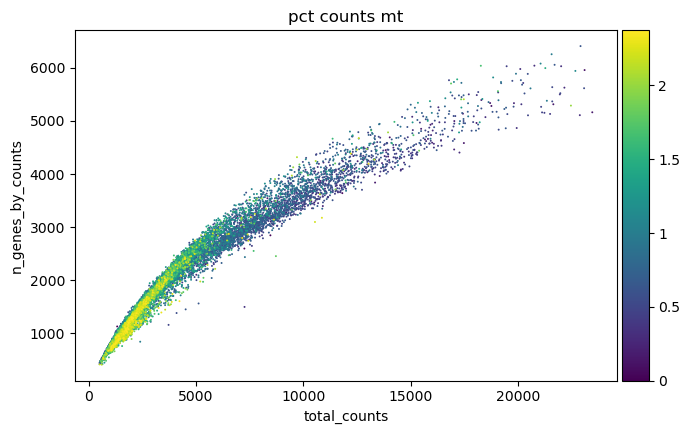

In [97]:
p1 = sc.pl.scatter(adata1, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [98]:
adata1.obs[adata1.obs['n_genes_by_counts'] < 500]

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,outlier,mt_outlier
ACACCCAGTTAGTGGA-1,474,6.163315,553.0,6.317165,12.477396,23.327306,32.368897,50.452080,100.0,3.0,1.386294,0.542495,17.0,2.890372,3.074141,0.0,0.000000,0.000000,False,False
ACACCCTCACTCAGGA-1,408,6.013715,611.0,6.416732,19.476268,31.914894,48.281506,65.957447,100.0,13.0,2.639057,2.127660,22.0,3.135494,3.600655,0.0,0.000000,0.000000,False,False
ACAGGATAGGCACGTT-1,488,6.192362,644.0,6.469250,14.751553,26.242236,39.751553,55.279503,100.0,11.0,2.484907,1.708074,25.0,3.258096,3.881988,1.0,0.693147,0.155280,False,False
ACCCAAATCATGGCCG-1,473,6.161207,623.0,6.436151,20.224719,29.855538,40.128411,56.179775,100.0,11.0,2.484907,1.765650,16.0,2.833213,2.568218,1.0,0.693147,0.160514,False,False
AGCGACAAGCCACATA-1,448,6.107023,511.0,6.238325,13.307241,22.113503,31.898239,51.467710,100.0,3.0,1.386294,0.587084,21.0,3.091043,4.109589,0.0,0.000000,0.000000,False,False
ATAACGTTCCAATGCA-1,446,6.102559,735.0,6.601230,23.265306,35.782313,49.387755,66.530612,100.0,10.0,2.397895,1.360544,22.0,3.135494,2.993197,0.0,0.000000,0.000000,False,False
ATGGAGTAGGTGCGTT-1,485,6.186209,561.0,6.331502,12.121212,22.459893,31.372549,49.197861,100.0,1.0,0.693147,0.178253,14.0,2.708050,2.495544,0.0,0.000000,0.000000,False,False
ATGTGAAAGGATCTCA-1,484,6.184149,625.0,6.439351,14.560000,24.480000,38.560000,54.560000,100.0,10.0,2.397895,1.600000,15.0,2.772589,2.400000,0.0,0.000000,0.000000,False,False
CGATGTCAGTACGGCT-1,450,6.111467,611.0,6.416732,16.857610,27.986907,42.716858,59.083470,100.0,12.0,2.564949,1.963994,17.0,2.890372,2.782324,1.0,0.693147,0.163666,False,False
CGCTACCTCTGTGCAA-1,470,6.154858,597.0,6.393591,16.750419,26.800670,38.023451,54.773869,100.0,9.0,2.302585,1.507538,15.0,2.772589,2.512563,1.0,0.693147,0.167504,False,False


In [99]:
adata1.var

,gene_ids,feature_types,genome,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
Xkr4,ENSMUSG00000051951,Gene Expression,GRCm39,False,False,False,358,0.046486,0.045438,97.821722,764.0,6.639876
Gm1992,ENSMUSG00000089699,Gene Expression,GRCm39,False,False,False,12,0.000852,0.000851,99.926985,14.0,2.708050
Gm19938,ENSMUSG00000102331,Gene Expression,GRCm39,False,False,False,32,0.002434,0.002431,99.805294,40.0,3.713572
Gm37381,ENSMUSG00000102343,Gene Expression,GRCm39,False,False,False,7,0.000487,0.000487,99.957408,8.0,2.197225
Rp1,ENSMUSG00000025900,Gene Expression,GRCm39,False,False,False,157,0.019227,0.019045,99.044722,316.0,5.758902
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000095523,ENSMUSG00000095523,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSMUSG00000095475,ENSMUSG00000095475,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSMUSG00000094855,ENSMUSG00000094855,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSMUSG00000095019,ENSMUSG00000095019,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000


In [100]:
adata1.var[adata1.var['n_cells_by_counts'] < 3]

,gene_ids,feature_types,genome,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
Gm37323,ENSMUSG00000104328,Gene Expression,GRCm39,False,False,False,1,0.000061,0.000061,99.993915,1.0,0.693147
Gm16041,ENSMUSG00000085623,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
Npbwr1,ENSMUSG00000033774,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
Gm30414,ENSMUSG00000103067,Gene Expression,GRCm39,False,False,False,2,0.000183,0.000183,99.987831,3.0,1.386294
Gm29520,ENSMUSG00000099827,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
ENSMUSG00000095763,ENSMUSG00000095763,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSMUSG00000095523,ENSMUSG00000095523,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSMUSG00000095475,ENSMUSG00000095475,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000
ENSMUSG00000094855,ENSMUSG00000094855,Gene Expression,GRCm39,False,False,False,0,0.000000,0.000000,100.000000,0.0,0.000000


# Ambient RNA check

In [101]:
import logging
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri

rcb.logger.setLevel(logging.ERROR)


%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [102]:
%%R
library(SoupX)

In [103]:
adata1_pp = adata1.copy()
sc.pp.normalize_total(adata1_pp, target_sum=1e4)
sc.pp.log1p(adata1_pp)

In [104]:
sc.pp.pca(adata1_pp)
sc.pp.neighbors(adata1_pp)
sc.tl.leiden(
    adata1_pp, key_added="soupx_groups", flavor="igraph", n_iterations=2, directed=False
)

# Preprocess variables for SoupX
adata1.obs["soupx_groups"] = adata1_pp.obs["soupx_groups"]

In [105]:
del adata1_pp
cells = adata1.obs_names
genes = adata1.var_names
data = adata1.X.T

In [106]:
adata1_raw = sc.read_10x_h5('/projects/circ_iri/work/cell_ranger/output/S26_17/outs/raw_feature_bc_matrix.h5')
adata1_raw.var_names_make_unique()

genes_raw = adata1_raw.var_names
cells_raw = adata1_raw.obs_names

data_tod = adata1_raw.X.T

/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/aumlauf/miniforge3/envs/circ_iri/lib/python3.11/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [107]:
del adata1_raw

In [108]:
data_csc = data.tocsc()
data_tod_csc = data_tod.tocsc()

# Extract sparse components and cast to correct types
x = data_csc.data.astype(np.float64)
i = data_csc.indices.astype(np.int32)
p = data_csc.indptr.astype(np.int32)
dims = np.array(data_csc.shape, dtype=np.int32)

x_tod = data_tod_csc.data.astype(np.float64)
i_tod = data_tod_csc.indices.astype(np.int32)
p_tod = data_tod_csc.indptr.astype(np.int32)
dims_tod = np.array(data_tod_csc.shape, dtype=np.int32)

with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter):
    ro.globalenv["x"] = x
    ro.globalenv["i"] = i
    ro.globalenv["p"] = p
    ro.globalenv["dims"] = dims

    ro.globalenv["x_tod"] = x_tod
    ro.globalenv["i_tod"] = i_tod
    ro.globalenv["p_tod"] = p_tod
    ro.globalenv["dims_tod"] = dims_tod

    ro.globalenv["genes"] = np.array(genes)
    ro.globalenv["genes_raw"] = np.array(genes_raw)
    ro.globalenv["cells"] = np.array(cells)
    ro.globalenv["cells_raw"] = np.array(cells_raw)
    ro.globalenv["soupx_groups"] = adata1.obs["soupx_groups"].to_numpy()

In [109]:
%%R -o out 

library(Matrix)

# Manually coerce types to avoid "array" class errors
x <- as.numeric(x)
i <- as.integer(i)
p <- as.integer(p)
dims <- as.integer(dims)

x_tod <- as.numeric(x_tod)
i_tod <- as.integer(i_tod)
p_tod <- as.integer(p_tod)
dims_tod <- as.integer(dims_tod)

# Reconstruct sparse matrices
data <- new("dgCMatrix",
            Dim = dims,
            x = x,
            i = i,
            p = p)

data_tod <- new("dgCMatrix",
                Dim = dims_tod,
                x = x_tod,
                i = i_tod,
                p = p_tod)

# Assign row and column names
rownames(data) <- genes
colnames(data) <- cells
rownames(data_tod) <- genes_raw
colnames(data_tod) <- cells_raw

# SoupX pipeline
sc = SoupChannel(data_tod, data, calcSoupProfile = TRUE)
sc = setClusters(sc, soupx_groups)
sc = autoEstCont(sc, doPlot = FALSE)
out = adjustCounts(sc, roundToInt = TRUE)

1061 genes passed tf-idf cut-off and 278 soup quantile filter.  Taking the top 100.
Using 1025 independent estimates of rho.
Estimated global rho of 0.05
Expanding counts from 25 clusters to 15223 cells.
In addition: Warning message:
In sparseMatrix(i = out@i[w] + 1, j = out@j[w] + 1, x = out@x[w],  :
  'giveCsparse' is deprecated; setting repr="T" for you


In [111]:
%%R -o out 
str(sc)

List of 5
 $ toc        :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. ..@ i       : int [1:30581530] 18 22 43 49 53 64 73 82 83 108 ...
  .. ..@ p       : int [1:15224] 0 1741 3199 5719 6605 7714 9265 11371 13497 15005 ...
  .. ..@ Dim     : int [1:2] 33696 15223
  .. ..@ Dimnames:List of 2
  .. .. ..$ :

 chr [1:33696] "Xkr4" "Gm1992" "Gm19938" "Gm37381" ...
  .. .. ..$ : chr [1:15223] "AAACCAAAGCGCCTGA-1" "AAACCAAAGGCGAGAC-1" "AAACCAAAGGCTCCGA-1" "AAACCAAAGGTGCAGA-1" ...
  .. ..@ x       : num [1:30581530] 1 2 3 2 1 1 1 1 1 2 ...
  .. ..@ factors : list()
 $ metaData   :'data.frame':	15223 obs. of  3 variables:
  ..$ nUMIs   : num [1:15223] 2887 2360 5668 1103 1730 ...
  ..$ clusters: chr [1:15223] "0" "0" "3" "4" ...
  ..$ rho     : num [1:15223] 0.049 0.049 0.049 0.049 0.049 0.049 0.049 0.049 0.049 0.049 ...
 $ nDropUMIs  : Named num [1:1961213] 1 1 1 2 0 3 1 2 2 1 ...
  ..- attr(*, "names")= chr [1:1961213] "AAACCAAAGAACCAGG-1" "AAACCAAAGAACCTAT-1" "AAACCAAAGAACGAGT-1" "AAACCAAAGAACGATA-1" ...
 $ soupProfile:'data.frame':	33696 obs. of  2 variables:
  ..$ est   : num [1:33696] 7.56e-06 4.20e-07 8.40e-07 0.00 3.36e-06 ...
  ..$ counts: num [1:33696] 18 1 2 0 8 14 0 0 204 4 ...
 $ fit        :List of 7
  ..$ dd            :'data.frame':	2500 obs. of  14 variables:
  .. ..$ gene      

In [114]:
with localconverter(ro.default_converter + pandas2ri.converter + numpy2ri.converter):
    out_py = ro.conversion.rpy2py(ro.globalenv["out"])

x = np.array(out_py.slots["x"])
i = np.array(out_py.slots["i"])
p = np.array(out_py.slots["p"])
shape = tuple(out_py.slots["Dim"])

out_matrix = csc_matrix((x, i, p), shape=shape)

In [116]:
adata1.layers["counts"] = adata1.X.copy()
adata1.layers["soupX_counts"] = out_matrix.T
adata1.X = adata1.layers["soupX_counts"]

In [117]:
print(f"Total number of genes: {adata1.n_vars}")

# Min 20 cells - filters out 0 count genes
sc.pp.filter_genes(adata1, min_cells=20)
print(f"Number of genes after cell filter: {adata1.n_vars}")

Total number of genes: 33696
Number of genes after cell filter: 18097
